In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

In [2]:
plt.rc('font', family='NanumBarunGothic')

In [31]:
df = pd.read_csv("./sample_data/ai4i2020.csv")
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


- UDI : 고유 식별자
- ProductID: 제품 고유 번호
- Type: 제품의 품질종류 (L: 저품질, M: 중간품질, H: 고품질)
- Air Temperature[K]: 공기온도
- Process Temperature[K]: 공정 과정에서의 온도
- Rotational Speed[RPM]: 기계의 분당 회전 속도
- Torque[Nm]: 회전력
- Tool Wear[Min]: 공구(칼날)가 마모된 시간
------------------------------------------------------
### Machine Failure: 기계 고장 여부
- TWF(Tool Wear Failure): 공구 마모로 인한 고장
- HDF(Heat Dissipation Failure): 열 방출 실패로 인한 과열 고장
- PWF(Power Failure): 전력 문제로 인한 고장
- OSF(Overstrain Failure): 과부화로 인한 고장
- RNF(Random Failure): 임의의 고장

## EDA(탐색적 데이터 분석) 및 전처리

In [ ]:
## 상위 5개
df.head()
## 메타데이터
df.info()
## 기술통계량
df.describe()

In [4]:
## 기계 고장 여부 파악
df["Machine failure"].value_counts()

,count
Machine failure,
0,9661
1,339


## matplotlib으로 Machine failure 시각화하기

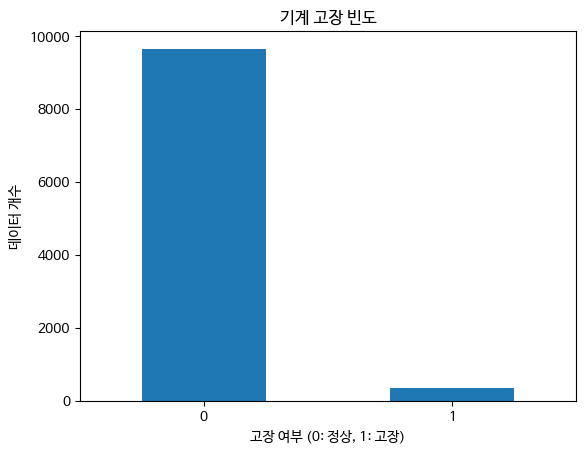

In [9]:
# 1. value_counts()로 데이터 개수를 계산합니다.
failure_counts = df['Machine failure'].value_counts()

# 2. 계산된 결과를 막대 그래프로 그립니다.
failure_counts.plot(kind='bar')

# 그래프 제목과 축 레이블 추가
plt.title('기계 고장 빈도')
plt.xlabel('고장 여부 (0: 정상, 1: 고장)')
plt.ylabel('데이터 개수')
plt.xticks(rotation=0) # x축 글자가 세로로 눕지 않도록 설정

# 그래프 보여주기
plt.show()

## Seaborn으로 Machine failure 시각화하기

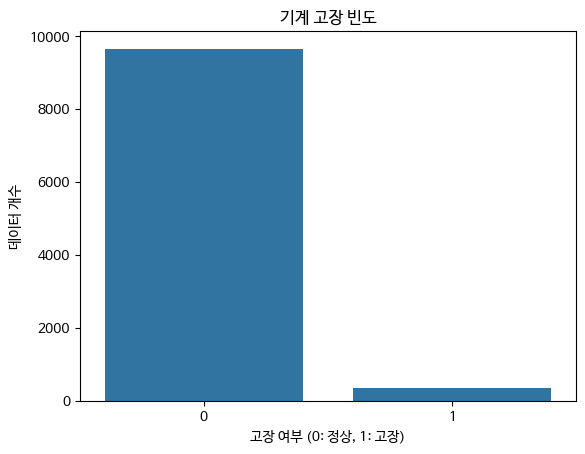

In [6]:
sns.countplot(x='Machine failure', data=df)

# 그래프 제목과 축 레이블 추가
plt.title('기계 고장 빈도')
plt.xlabel('고장 여부 (0: 정상, 1: 고장)')
plt.ylabel('데이터 개수')

# 그래프 보여주기
plt.show()

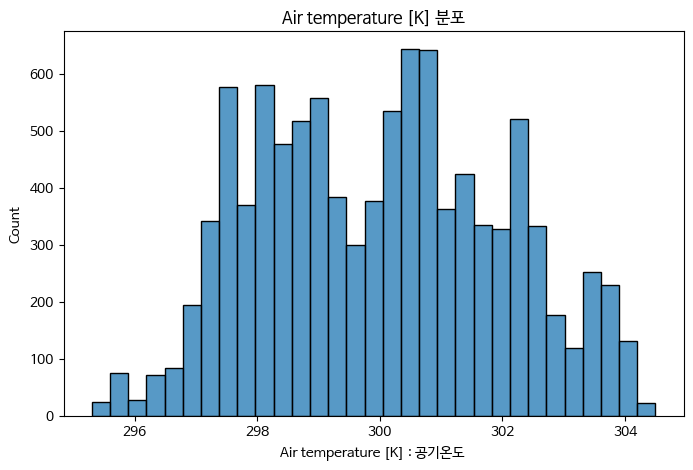

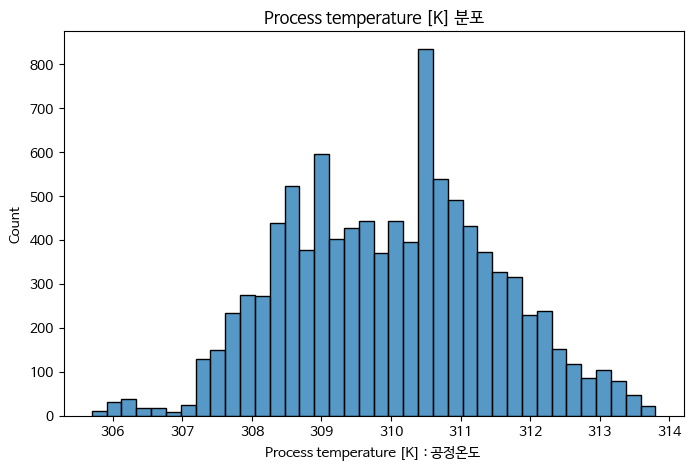

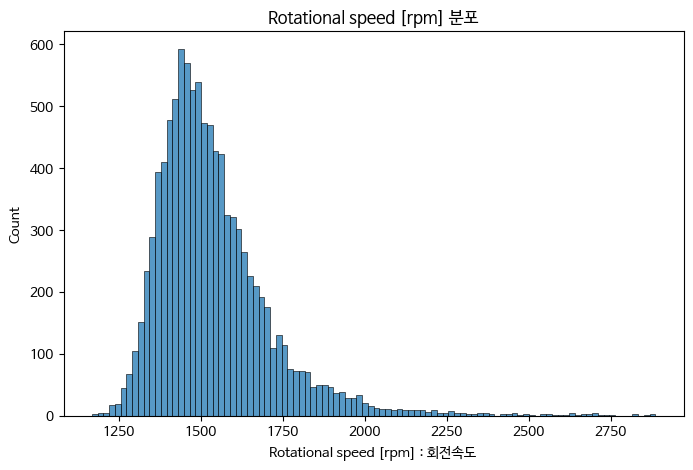

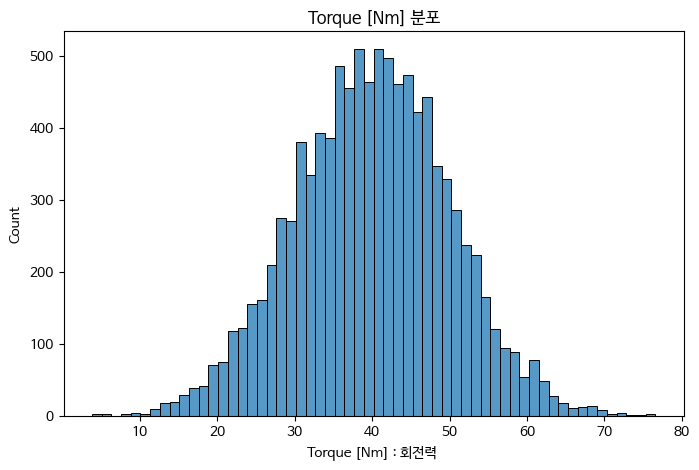

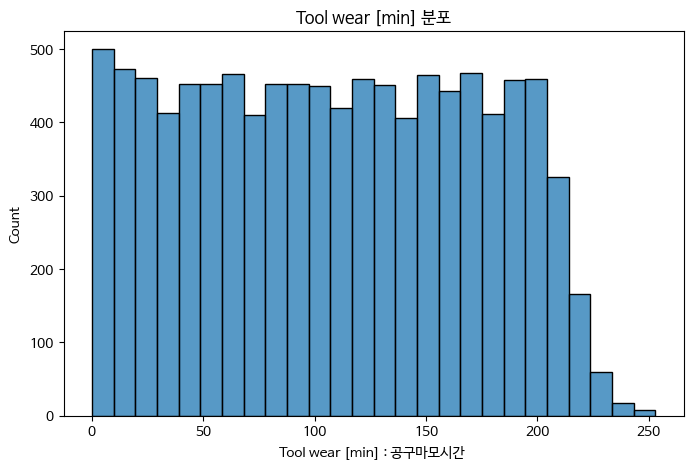

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# 분석할 주요 센서 칼럼 리스트
features = {
    'Air temperature [K]' : '공기온도',
    'Process temperature [K]' : '공정온도',
    'Rotational speed [rpm]' :'회전속도',
    'Torque [Nm]' : '회전력',
    'Tool wear [min]': '공구마모시간'
}

# 각 feature에 대한 히스토그램 그리기
for feature in features:
    plt.figure(figsize=(8, 4)) # 그래프 사이즈 조절
    sns.histplot(data=df, x=feature)
    plt.title(f'{feature} 분포')
    plt.xlabel(f'{feature} : {features[feature]} ')
    plt.show()

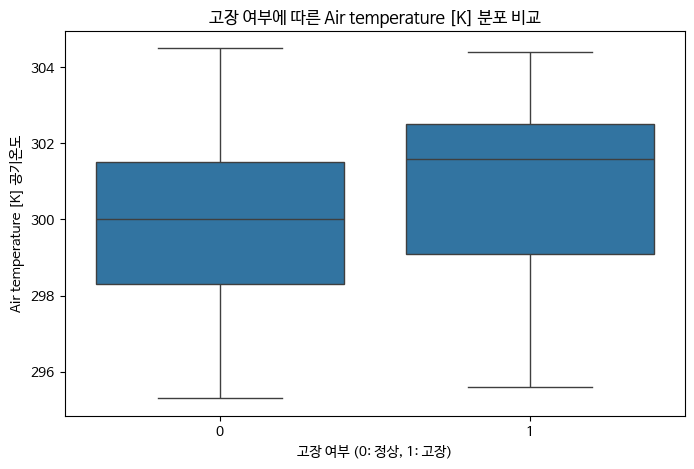

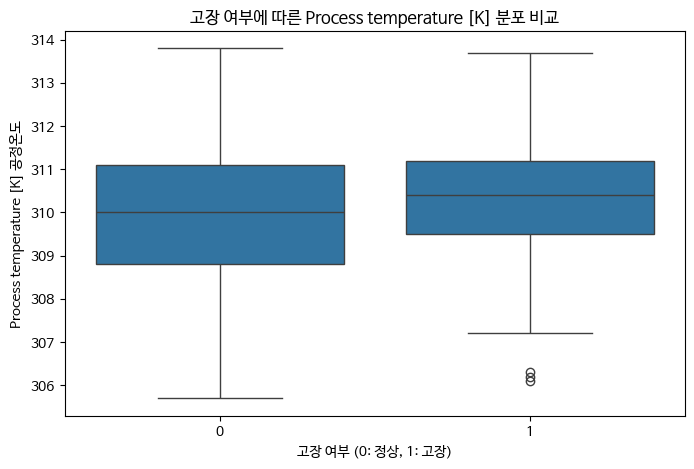

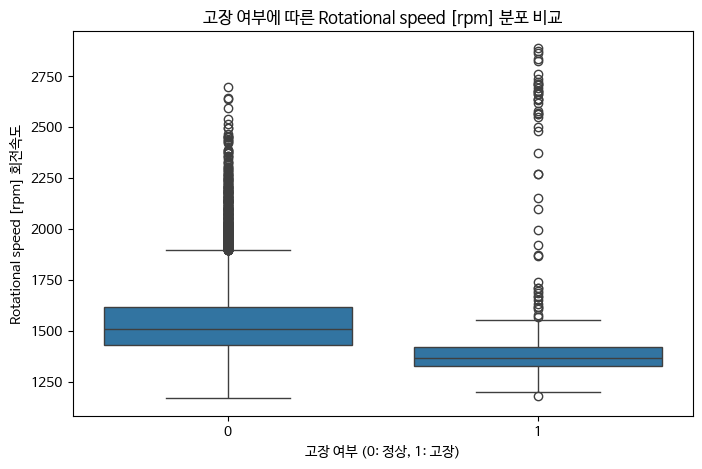

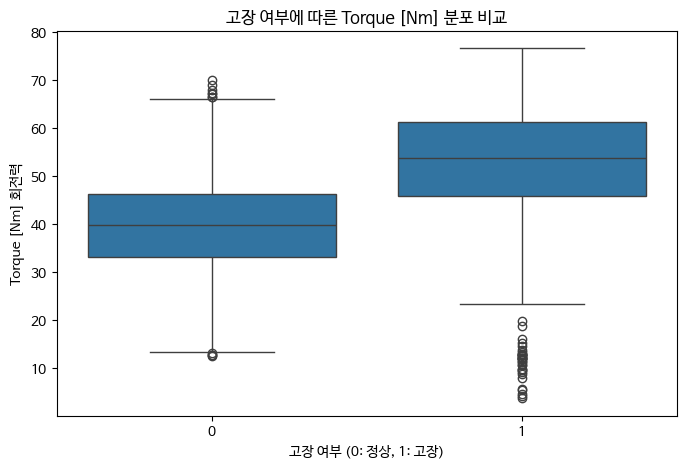

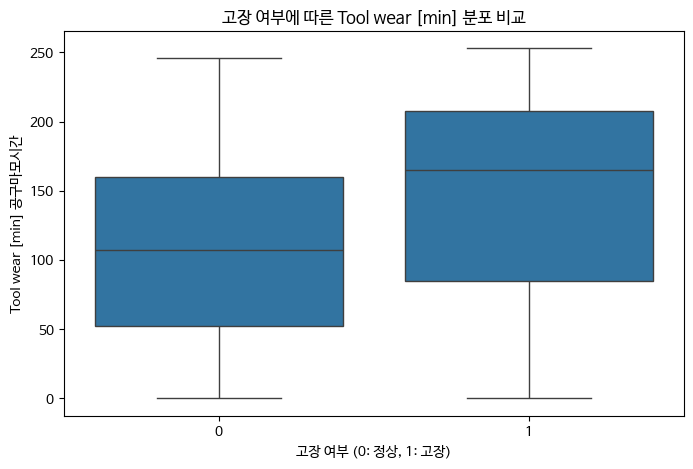

In [20]:
# 각 feature를 'Machine failure'에 따라 비교하는 boxplot 그리기
for feature in features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='Machine failure', y=feature)
    plt.title(f'고장 여부에 따른 {feature} 분포 비교')
    plt.xlabel('고장 여부 (0: 정상, 1: 고장)')
    plt.ylabel(f'{feature} {features[feature]}')
    plt.show()

In [24]:
df_data = df.drop(columns=['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
df_data

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0
...,...,...,...,...,...,...,...
9995,M,298.8,308.4,1604,29.5,14,0
9996,H,298.9,308.4,1632,31.8,17,0
9997,M,299.0,308.6,1645,33.4,22,0
9998,H,299.0,308.7,1408,48.5,25,0


## 변사 간의 상관관계 히트맵

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


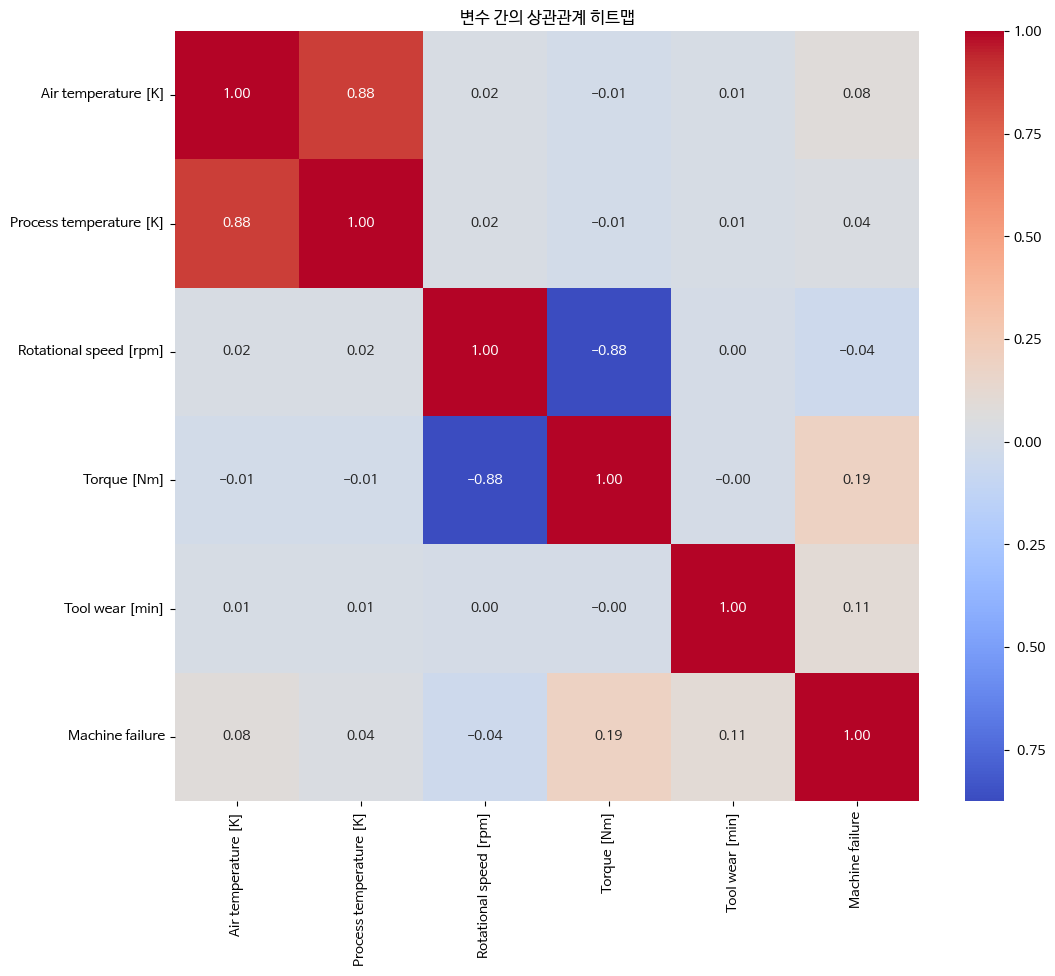

In [25]:
corr_matrix = df_data.corr(numeric_only=True)

# 2. 계산된 상관관계 행렬을 히트맵으로 그립니다.
plt.figure(figsize=(12, 10)) # 그래프 사이즈를 키워서 잘 보이게 설정
sns.heatmap(
    corr_matrix,
    annot=True,      # 각 셀에 숫자 값을 표시합니다.
    fmt='.2f',       # 숫자 값을 소수점 둘째 자리까지만 표시합니다.
    cmap='coolwarm'  # 색상 테마를 지정합니다. (양수는 따뜻한 색, 음수는 차가운 색)
)
plt.title('변수 간의 상관관계 히트맵')
plt.show()

## 정리
1. 기계 고장률은 0.03
2. Air temperature(공기 온도), Process temperature(공정 온도), Rotational speed(회전 속도), Torque(회전력), Tool wear(공구 마모시간)
3. boxPlot 의거하여 고장 여부와 상관관계가 있을만할 변수는 Torque가 연관되어 있다고 예측
4. Air tempeature, Process temperature는 양의 상관관계, Roataional speed, Torque는 음의 상관관계
5. Machinal failure는 Torque, Tool wear, Air temperature, Process temperature, Rotaional speed 순으로 연관

---

## 데이터 전처리

In [28]:
## one-hot encoding
df_encoded = pd.get_dummies(df, columns=['Type'], drop_first=True)

,UDI,Product ID,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_L,Type_M
0,1,M14860,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,False,True
1,2,L47181,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,True,False
2,3,L47182,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,True,False
3,4,L47183,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,True,False
4,5,L47184,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,True,False


In [32]:
## label encoding
type_mapping = {'L': 0, 'M': 1, 'H': 2}

# 2. 'Type' 칼럼에 map 함수를 적용하여 값을 변경합니다.
df['Type'] = df['Type'].map(type_mapping)

df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,1,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,0,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,0,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,0,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,0,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,1,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,2,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,1,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,2,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [55]:
df = df.drop(columns=["Product ID"])

In [56]:
from sklearn.model_selection import train_test_split

# 1. Feature(문제지)와 Target(정답지)을 먼저 정의합니다.
#    'Machine failure'가 우리가 예측할 목표(Target)이고, 나머지는 모두 Feature입니다.
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

# 2. 데이터를 학습용과 테스트용으로 8:2 비율로 나눕니다.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,     # 테스트용 데이터 비율을 20%로 지정
    random_state=42,   # 코드를 다시 실행해도 항상 똑같이 데이터가 나뉘도록 설정
    stratify=y         # 고장/정상 데이터의 비율을 학습용과 테스트용에서 동일하게 유지
)

# 3. 나눠진 데이터의 크기를 확인합니다.
print("학습용 데이터(X_train) 크기:", X_train.shape)
print("테스트용 데이터(X_test) 크기:", X_test.shape)

학습용 데이터(X_train) 크기: (8000, 12)
테스트용 데이터(X_test) 크기: (2000, 12)


In [57]:
# 1. StandardScaler 객체를 생성합니다.
scaler = StandardScaler()

# 2. 스케일링할 숫자형 칼럼만 선택합니다. (문자열, ID 칼럼 제외)
numeric_cols = X_train.select_dtypes(include=['number']).columns

# 3. 중요! 학습용(X_train) 데이터의 숫자 칼럼에만 'fit'하고 'transform'을 적용합니다.
#    이렇게 하면 scaler가 X_train의 평균과 표준편차를 학습합니다.
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# 4. 테스트용(X_test) 데이터에는 학습된 scaler를 그대로 사용하여 'transform'만 적용합니다.
#    'fit'을 또 하면 안 됩니다! 시험지의 통계 정보를 미리 보는 것과 같습니다.
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# 5. 스케일링 결과 확인 (처음 5줄 출력)
print("--- 스케일링 후 학습용 데이터 ---")
print(X_train.head())

--- 스케일링 후 학습용 데이터 ---
           UDI      Type  Air temperature [K]  Process temperature [K]  \
4058 -0.326679  0.755329             0.998914                 0.604282   
1221 -1.308501  0.755329            -1.505194                -1.153260   
6895  0.655143  0.755329             0.498092                 1.077466   
9863  1.682301 -0.740002            -0.553633                -0.139294   
8711  1.283620 -0.740002            -1.455112                -1.018064   

      Rotational speed [rpm]  Torque [Nm]  Tool wear [min]       TWF  \
4058               -0.460607     0.718305        -0.843997 -0.067233   
1221               -0.775574     0.638456         0.382263 -0.067233   
6895               -1.007654     0.558607         0.460870 -0.067233   
9863               -0.709265     1.626586        -0.372359 -0.067233   
8711                1.070019    -1.128202        -0.906882 -0.067233   

           HDF       PWF       OSF        RNF  
4058 -0.104244 -0.101765 -0.101765  -0.043342  
122

In [58]:
model = LogisticRegression(random_state=42)

# 2. 모델 학습시키기: '학습용 데이터' (X_train, y_train)를 주고 공부시킵니다.
#    (이때 X_train은 피처 스케일링까지 완료된 데이터여야 합니다.)
model.fit(X_train, y_train)

# 3. 모델로 예측하기: 학습이 끝난 모델에게 '시험지'(X_test)를 주고 답을 예측하게 합니다.
y_pred = model.predict(X_test)

# 4. 모델 성능 평가하기: 모델의 예측 답안(y_pred)과 실제 정답(y_test)을 비교하여 채점합니다.
print("--- 로지스틱 회귀 모델 평가 결과 ---")
print(classification_report(y_test, y_pred))

--- 로지스틱 회귀 모델 평가 결과 ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



## 정리
- Percision : 정밀도
- Recail : 재현율
- F1-Score : F1 점수
- support : 실제 데이터 개수(len(X_test) : 2000)
